In [1]:
!pip -q install gdown nltk

from pathlib import Path
import os, re, json, pickle, random, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
if not tf.config.list_physical_devices('GPU'):
    print('WARNING: Enable a GPU from Runtime > Change runtime type.')


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download and verify Flickr8k

In [2]:
# Download Flickr8k from Kaggle instead of Google Drive

!pip install -q --upgrade kagglehub

import kagglehub
from pathlib import Path
import shutil

# Download the public Flickr8k dataset
dataset_path = Path(
    kagglehub.dataset_download("adityajn105/flickr8k")
)

print("Downloaded dataset location:", dataset_path)

# Automatically find the image directory
image_directories = [
    directory
    for directory in dataset_path.rglob("*")
    if directory.is_dir()
    and (
        len(list(directory.glob("*.jpg"))) > 100
        or len(list(directory.glob("*.jpeg"))) > 100
    )
]

if not image_directories:
    raise FileNotFoundError(
        f"Could not find the Flickr8k image directory inside {dataset_path}"
    )

IMAGE_DIR = max(
    image_directories,
    key=lambda directory: (
        len(list(directory.glob("*.jpg")))
        + len(list(directory.glob("*.jpeg")))
    )
)

# Automatically find the caption file
caption_candidates = (
    list(dataset_path.rglob("captions.txt"))
    + list(dataset_path.rglob("captions.csv"))
    + list(dataset_path.rglob("Flickr8k.token.txt"))
)

if not caption_candidates:
    raise FileNotFoundError(
        f"Could not find the caption file inside {dataset_path}"
    )

CAPTION_FILE = caption_candidates[0]

# Directory used for trained models and evaluation results
OUTPUT_DIR = Path("outputs_scratch_cnn_lstm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Find all supported images
image_files = (
    list(IMAGE_DIR.glob("*.jpg"))
    + list(IMAGE_DIR.glob("*.jpeg"))
    + list(IMAGE_DIR.glob("*.png"))
)

assert IMAGE_DIR.exists(), "The image directory does not exist."
assert CAPTION_FILE.exists(), "The caption file does not exist."
assert len(image_files) > 0, "No images were found."

print("\nDataset preparation completed")
print("Image directory:", IMAGE_DIR)
print("Caption file:", CAPTION_FILE)
print(f"Number of images: {len(image_files):,}")

Using Colab cache for faster access to the 'flickr8k' dataset.
Downloaded dataset location: /kaggle/input/flickr8k

Dataset preparation completed
Image directory: /kaggle/input/flickr8k/Images
Caption file: /kaggle/input/flickr8k/captions.txt
Number of images: 8,091


## 3. Load and clean captions

Cleaning keeps alphabetic words and apostrophes, removes isolated one-character tokens, and adds explicit `startseq` / `endseq` tokens. We keep all reference captions for evaluation.


In [3]:
df = pd.read_csv(CAPTION_FILE)
print('Columns:', df.columns.tolist())

# Support the standard Flickr8k CSV and minor column-name variations.
image_col = next((c for c in df.columns if c.lower() in {'image', 'image_name', 'filename'}), df.columns[0])
caption_col = next((c for c in df.columns if c.lower() in {'caption', 'captions', 'description'}), df.columns[1])
df = df[[image_col, caption_col]].dropna().rename(columns={image_col: 'image', caption_col: 'caption'})

available = {p.name: str(p) for p in IMAGE_DIR.iterdir() if p.is_file()}
df = df[df['image'].astype(str).isin(available)].copy()

def clean_caption(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z']+", ' ', text)
    words = [w for w in text.split() if len(w) > 1 or w in {'a', 'i'}]
    return 'startseq ' + ' '.join(words) + ' endseq'

df['caption_clean'] = df['caption'].map(clean_caption)
df['image_path'] = df['image'].map(available)
df = df[df['caption_clean'].str.split().str.len() >= 4].reset_index(drop=True)

print(f'{df.image.nunique():,} images, {len(df):,} captions')
display(df.head())


Columns: ['image', 'caption']
8,091 images, 40,453 captions


,image,caption,caption_clean,image_path
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,startseq a child in a pink dress is climbing u...,/kaggle/input/flickr8k/Images/1000268201_693b0...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,startseq a girl going into a wooden building e...,/kaggle/input/flickr8k/Images/1000268201_693b0...
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,startseq a little girl climbing into a wooden ...,/kaggle/input/flickr8k/Images/1000268201_693b0...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,startseq a little girl climbing the stairs to ...,/kaggle/input/flickr8k/Images/1000268201_693b0...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,startseq a little girl in a pink dress going i...,/kaggle/input/flickr8k/Images/1000268201_693b0...


## 4. Leakage-free image-level split

All five captions belonging to an image stay in the same split. This prevents the model from seeing an image during training and then being evaluated on another caption for that same image.


In [4]:
all_images = np.array(sorted(df['image'].unique()))
train_images, temp_images = train_test_split(all_images, test_size=0.20, random_state=SEED)
val_images, test_images = train_test_split(temp_images, test_size=0.50, random_state=SEED)

split_map = ({name: 'train' for name in train_images} |
             {name: 'val' for name in val_images} |
             {name: 'test' for name in test_images})
df['split'] = df['image'].map(split_map)

for split in ['train', 'val', 'test']:
    part = df[df.split == split]
    print(f'{split:5s}: {part.image.nunique():4d} images | {len(part):5d} captions')
assert set(train_images).isdisjoint(val_images)
assert set(train_images).isdisjoint(test_images)
assert set(val_images).isdisjoint(test_images)


train: 6472 images | 32358 captions
val  :  809 images |  4045 captions
test :  810 images |  4050 captions


## 5. Train-only vocabulary and padded sequences

`num_words` limits rare words, which reduces the softmax layer and helps a small dataset. The tokenizer is fitted **only on training captions**. Validation/test-only words become `unk` rather than leaking into training metadata.


In [5]:
MAX_VOCAB = 6000
MAX_LENGTH_CAP = 35

tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=MAX_VOCAB,
    oov_token='unk',
    filters=''  # text is already cleaned
)
train_texts = df.loc[df.split == 'train', 'caption_clean'].tolist()
tokenizer.fit_on_texts(train_texts)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
train_lengths = [len(x.split()) for x in train_texts]
MAX_LEN = min(MAX_LENGTH_CAP, int(np.percentile(train_lengths, 99)))
START_ID = tokenizer.word_index['startseq']
END_ID = tokenizer.word_index['endseq']

def encode_captions(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAX_LEN, padding='post', truncating='post'
    ).astype('int32')

df['encoded'] = list(encode_captions(df.caption_clean.tolist()))
print('Vocabulary size:', VOCAB_SIZE)
print('Sequence length:', MAX_LEN)
print('start/end IDs:', START_ID, END_ID)


Vocabulary size: 6000
Sequence length: 24
start/end IDs: 3 4


## 6. Efficient `tf.data` pipeline

For teacher forcing, the decoder input is every token except the last and the target is every token except the first. Padding positions receive zero weight, so they do not inflate accuracy or affect loss.


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.15),
], name='augmentation')

def load_example(path, sequence, training=False):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    image = tf.cast(image, tf.float32) / 255.0
    if training:
        image = augmentation(image, training=True)
    decoder_in = sequence[:-1]
    target = sequence[1:]
    weights = tf.cast(target != 0, tf.float32)
    return {'image': image, 'tokens': decoder_in}, target, weights

def make_dataset(split, training=False):
    part = df[df.split == split]
    paths = part.image_path.astype(str).to_numpy()
    sequences = np.stack(part.encoded.to_numpy())
    ds = tf.data.Dataset.from_tensor_slices((paths, sequences))
    if training:
        ds = ds.shuffle(min(len(part), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, s: load_example(p, s, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset('train', training=True)
val_ds = make_dataset('val')
test_ds = make_dataset('test')

batch = next(iter(train_ds))
print('Image batch:', batch[0]['image'].shape)
print('Token batch:', batch[0]['tokens'].shape)
print('Target batch:', batch[1].shape)


Image batch: (32, 224, 224, 3)
Token batch: (32, 23)
Target batch: (32, 23)


## 7. Scratch residual CNN + LSTM decoder

The CNN uses random initialization and is optimized end-to-end. Its visual vector initializes both LSTM states. Residual connections and batch normalization stabilize deeper scratch training; global average pooling controls parameter count.


In [7]:
L2 = 1e-5
EMBED_DIM = 256
LSTM_UNITS = 512

def conv_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False,
                      kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    return layers.Activation('swish')(layers.Add()([x, shortcut]))

image_in = layers.Input((IMG_SIZE, IMG_SIZE, 3), name='image')
x = layers.Conv2D(32, 5, strides=2, padding='same', use_bias=False,
                  kernel_initializer='he_normal')(image_in)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)
x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
for filters, stride in [(64, 1), (96, 2), (128, 2), (192, 2), (256, 2)]:
    x = conv_block(x, filters, stride)
    x = conv_block(x, filters, 1)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
h0 = layers.Dense(LSTM_UNITS, activation='tanh', name='initial_h')(x)
c0 = layers.Dense(LSTM_UNITS, activation='tanh', name='initial_c')(x)

token_in = layers.Input((MAX_LEN - 1,), dtype='int32', name='tokens')
t = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name='embedding')(token_in)
t = layers.SpatialDropout1D(0.25)(t)
t = layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=0.25,
                recurrent_dropout=0.0, name='caption_lstm')(t, initial_state=[h0, c0])
t = layers.Dense(512, activation='swish')(t)
t = layers.Dropout(0.30)(t)
logits = layers.Dense(VOCAB_SIZE, name='word_logits')(t)

model = keras.Model({'image': image_in, 'tokens': token_in}, logits, name='scratch_cnn_lstm')
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-5, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy(name='masked_accuracy')]
)
model.summary()
print('Pretrained weights used: NONE')


Model: "scratch_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      2,400 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 11,240,656 (42.88 MB)

 Trainable params: 11,233,232 (42.85 MB)

 Non-trainable params: 7,424 (29.00 KB)

Pretrained weights used: NONE


## 8. Train with stable callbacks

The best checkpoint is selected by validation loss. Set `EPOCHS` lower for a quick pipeline test (for example 2), then restore it for the real experiment.


In [8]:
EPOCHS = 30
CHECKPOINT = OUTPUT_DIR / 'best_scratch_cnn_lstm.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(CHECKPOINT, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                                      min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.CSVLogger(OUTPUT_DIR / 'training_log.csv')
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)


Epoch 1/30
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - loss: 4.7216 - masked_accuracy: 0.2081
Epoch 1: val_loss improved from None to 3.51901, saving model to outputs_scratch_cnn_lstm/best_scratch_cnn_lstm.keras

Epoch 1: finished saving model to outputs_scratch_cnn_lstm/best_scratch_cnn_lstm.keras
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 640s 602ms/step - loss: 4.1250 - masked_accuracy: 0.2532 - val_loss: 3.5190 - val_masked_accuracy: 0.3092 - learning_rate: 3.0000e-04
Epoch 2/30
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - loss: 3.5010 - masked_accuracy: 0.3102
Epoch 2: val_loss improved from 3.51901 to 3.26005, saving model to outputs_scratch_cnn_lstm/best_scratch_cnn_lstm.keras

Epoch 2: finished saving model to outputs_scratch_cnn_lstm/best_scratch_cnn_lstm.keras
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 605s 597ms/step - loss: 3.4267 - masked_accuracy: 0.3157 - val_loss: 3.2601 - val_masked_accuracy: 0.3314 - learning_rate: 3.0000e-04
Epoch 3/30
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - los

## 9. Learning curves and masked test metrics

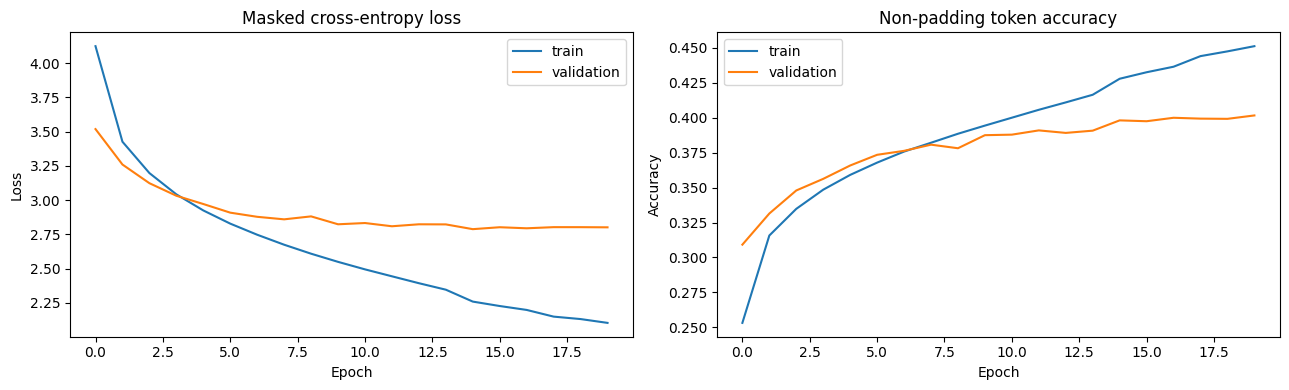

127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 183ms/step - loss: 2.7774 - masked_accuracy: 0.3938
{'loss': 2.7774, 'masked_accuracy': 0.3938}


In [9]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist['loss'], label='train')
axes[0].plot(hist['val_loss'], label='validation')
axes[0].set(title='Masked cross-entropy loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend()
axes[1].plot(hist['masked_accuracy'], label='train')
axes[1].plot(hist['val_masked_accuracy'], label='validation')
axes[1].set(title='Non-padding token accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=160)
plt.show()

test_metrics = model.evaluate(test_ds, return_dict=True)
print({k: round(float(v), 4) for k, v in test_metrics.items()})


## 10. Correct greedy and beam-search caption generation

Unlike the original loop, decoding tests token IDs directly and stops at `endseq`. Beam search retains several promising partial sentences rather than making an irreversible greedy choice at every word.


## 11. Quantitative caption evaluation with corpus BLEU

In [12]:
index_word = {i: w for w, i in tokenizer.word_index.items() if i < VOCAB_SIZE}

def prepare_image(image_path):
    raw = tf.io.read_file(str(image_path))
    image = tf.io.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    return tf.cast(image, tf.float32)[None, ...] / 255.0

def next_log_probs(image, token_ids):
    padded = keras.preprocessing.sequence.pad_sequences(
        [token_ids], maxlen=MAX_LEN - 1, padding='post', truncating='post'
    )
    # Convert padded numpy array to TensorFlow tensor
    padded = tf.convert_to_tensor(padded, dtype=tf.int32)
    logits = model({'image': image, 'tokens': padded}, training=False)
    position = min(len(token_ids), MAX_LEN - 1) - 1
    return tf.nn.log_softmax(logits[0, position]).numpy()

def ids_to_caption(ids):
    words = [index_word.get(i, 'unk') for i in ids if i not in {0, START_ID, END_ID}]
    return ' '.join(words)

def greedy_caption(image_path):
    image, ids = prepare_image(image_path), [START_ID]
    for _ in range(MAX_LEN - 2):
        next_id = int(np.argmax(next_log_probs(image, ids)))
        if next_id in {0, END_ID}:
            break
        ids.append(next_id)
    return ids_to_caption(ids)

def beam_caption(image_path, beam_width=3, length_penalty=0.7):
    image = prepare_image(image_path)
    beams = [([START_ID], 0.0, False)]
    for _ in range(MAX_LEN - 2):
        candidates = []
        for ids, score, ended in beams:
            if ended:
                candidates.append((ids, score, ended))
                continue
            logp = next_log_probs(image, ids)
            top_ids = np.argpartition(logp, -beam_width)[-beam_width:]
            for token_id in top_ids:
                token_id = int(token_id)
                candidates.append((ids + [token_id], score + float(logp[token_id]),
                                   token_id in {0, END_ID}))
        beams = sorted(candidates,
                       key=lambda z: z[1] / (max(1, len(z[0]) - 1) ** length_penalty),
                       reverse=True)[:beam_width]
        if all(x[2] for x in beams):
            break
    best = max(beams, key=lambda z: z[1] / (max(1, len(z[0]) - 1) ** length_penalty))
    return ids_to_caption(best[0])

In [13]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

test_refs = (df[df.split == 'test']
             .groupby('image')['caption_clean']
             .apply(lambda xs: [[w for w in x.split() if w not in {'startseq', 'endseq'}] for x in xs])
             .to_dict())

references, hypotheses = [], []
for image_name, refs in tqdm(test_refs.items(), desc='Generating test captions'):
    prediction = beam_caption(available[image_name], beam_width=3).split()
    references.append(refs)
    hypotheses.append(prediction)

smooth = SmoothingFunction().method1
bleu_scores = {
    'BLEU-1': corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smooth),
    'BLEU-2': corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth),
    'BLEU-3': corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smooth),
    'BLEU-4': corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth),
}
print({k: round(v, 4) for k, v in bleu_scores.items()})

with open(OUTPUT_DIR / 'test_metrics.json', 'w') as f:
    json.dump({'token_metrics': {k: float(v) for k, v in test_metrics.items()},
               'bleu': bleu_scores}, f, indent=2)


Generating test captions:   0%|          | 0/810 [00:00<?, ?it/s]

{'BLEU-1': 0.4974, 'BLEU-2': 0.3207, 'BLEU-3': 0.2059, 'BLEU-4': 0.1374}


## 12. Visual inspection on unseen test images

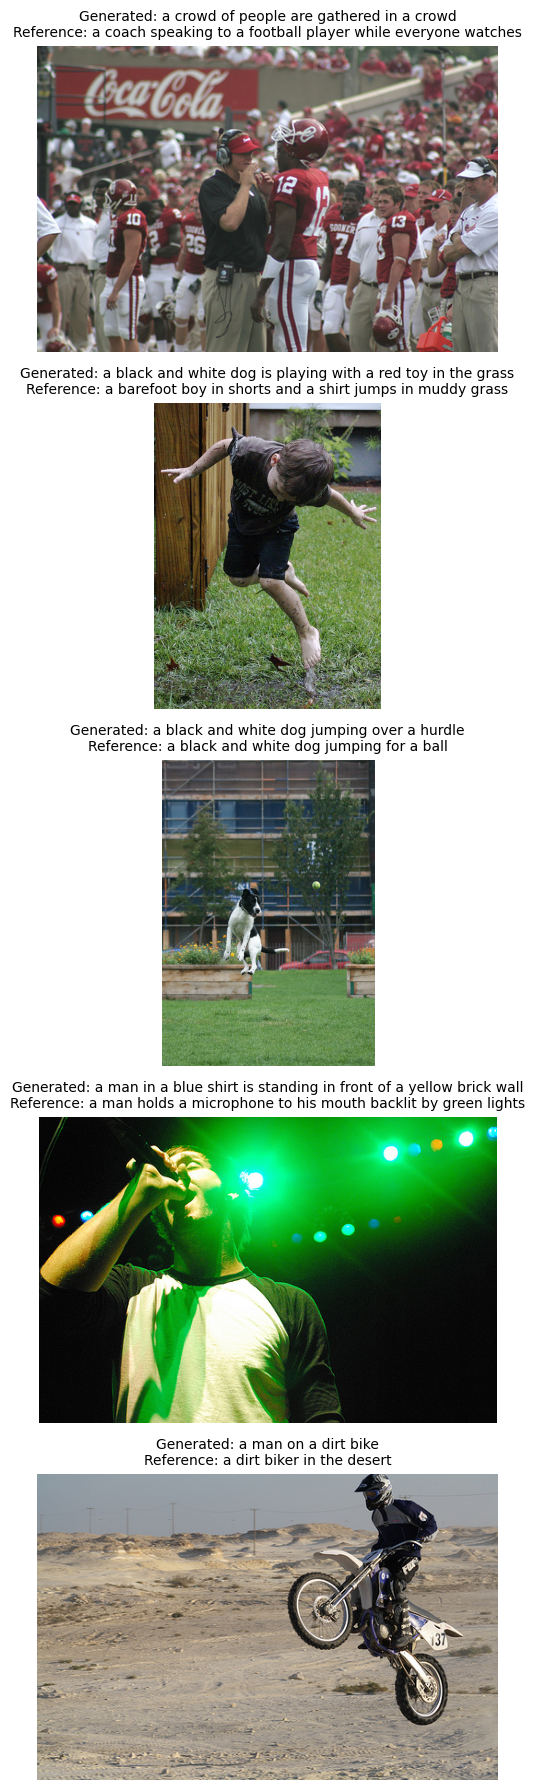

In [14]:
sample_names = np.random.default_rng(SEED).choice(test_images, size=5, replace=False)
fig, axes = plt.subplots(len(sample_names), 1, figsize=(12, 18))
for ax, image_name in zip(axes, sample_names):
    image_path = available[image_name]
    ax.imshow(Image.open(image_path).convert('RGB'))
    refs = [x.replace('startseq ', '').replace(' endseq', '')
            for x in df.loc[df.image == image_name, 'caption_clean'].tolist()]
    pred = beam_caption(image_path, beam_width=3)
    ax.set_title(f'Generated: {pred}\nReference: {refs[0]}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_predictions.png', dpi=160, bbox_inches='tight')
plt.show()


## 13. Save reproducibility artifacts

The split, tokenizer, configuration, best model, logs, plots, and metrics are bundled. Keep these artifacts when reporting results so the experiment can be reproduced.


In [15]:
# Save exact splits and preprocessing state.
split_df = pd.DataFrame({
    'image': all_images,
    'split': [split_map[x] for x in all_images]
})
split_df.to_csv(OUTPUT_DIR / 'image_splits.csv', index=False)

with open(OUTPUT_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
config = {
    'seed': SEED, 'image_size': IMG_SIZE, 'max_len': MAX_LEN,
    'vocab_size': VOCAB_SIZE, 'batch_size': BATCH_SIZE,
    'embedding_dim': EMBED_DIM, 'lstm_units': LSTM_UNITS,
    'pretrained_model_or_weights': False,
}
with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

model.save(OUTPUT_DIR / 'final_scratch_cnn_lstm.keras')
archive = shutil.make_archive(str(OUTPUT_DIR), 'zip', root_dir=OUTPUT_DIR)
print('Saved artifacts:', archive)

from google.colab import files
# Uncomment to download all outputs after training:
# files.download(archive)


Saved artifacts: /content/outputs_scratch_cnn_lstm.zip
